## Dataset Preparation

In [ ]:
!pip install transformers
!pip install -q transformers datasets
!pip install transformers[torch]

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 13.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.8/268.8 kB 24.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 33.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 33.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 519.3/519.3 kB 6.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.3/115.3 kB 10.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 10.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 10.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.2/251.2 kB 3.8 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
import torch
import torch.nn as nn
import numpy as np
import ast
from datasets import Dataset, DatasetDict
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score
from transformers import RobertaTokenizerFast, RobertaForSequenceClassification, Trainer, TrainingArguments
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import BertTokenizerFast, BertForSequenceClassification
from transformers import EvalPrediction
import os
from datasets import load_dataset

In [ ]:
if torch.cuda.is_available():
    device = torch.cuda.get_device_name(0)
    print('GPU device:', device)
else:
    print('No GPU available.')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

No GPU available.


In [ ]:
drive.mount('/content/gdrive')
df = pd.read_csv('/content/gdrive/My Drive/MSc Project/fabsa.csv')


Mounted at /content/gdrive


Convert the representation of 'labels' and split the data

In [ ]:
# Convert the string representation of lists in 'labels' column to actual list
df['labels'] = df['labels'].apply(ast.literal_eval)

# Now you can generate the unique list of labels as before
labels = list(set([label for sublist in df['labels'].tolist() for label in sublist]))
id2label = {idx: label for idx, label in enumerate(labels)}
label2id = {label: idx for idx, label in enumerate(labels)}

Load dataset

In [ ]:
# Load data set and convert the string representation of lists in 'labels' column to actual list for each train and val data set
train_subset01 = pd.read_csv("/content/gdrive/My Drive/MSc Project/train_subset.csv", converters={'labels': ast.literal_eval})
val_df = pd.read_csv("/content/gdrive/My Drive/MSc Project/val_df.csv", converters={'labels': ast.literal_eval})

# Convert the pandas DataFrame to a Hugging Face Dataset
train_dataset = Dataset.from_pandas(train_subset01)
val_dataset = Dataset.from_pandas(val_df)

all_datasets = {}

dataset_key = "original_subset01"

# Combine them into a DatasetDict
dataset = DatasetDict({
        'train': train_dataset,
        'validation': val_dataset
    })

all_datasets[dataset_key] = dataset

In [ ]:
# Load data set and convert the string representation of lists in 'labels' column to actual list for each train and val data set
train_subset05 = pd.read_csv("/content/gdrive/My Drive/MSc Project/train_subset5.csv", converters={'labels': ast.literal_eval})
val_df = pd.read_csv("/content/gdrive/My Drive/MSc Project/val_df.csv", converters={'labels': ast.literal_eval})

# Convert the pandas DataFrame to a Hugging Face Dataset
train_dataset = Dataset.from_pandas(train_subset05)
val_dataset = Dataset.from_pandas(val_df)

dataset_key = "original_subset05"

# Combine them into a DatasetDict
dataset = DatasetDict({
        'train': train_dataset,
        'validation': val_dataset
    })

all_datasets[dataset_key] = dataset

In [ ]:
# Load data set and convert the string representation of lists in 'labels' column to actual list for each train and val data set
train_subset10 = pd.read_csv("/content/gdrive/My Drive/MSc Project/train_subset10.csv", converters={'labels': ast.literal_eval})
val_df = pd.read_csv("/content/gdrive/My Drive/MSc Project/val_df.csv", converters={'labels': ast.literal_eval})

# Convert the pandas DataFrame to a Hugging Face Dataset
train_dataset = Dataset.from_pandas(train_subset10)
val_dataset = Dataset.from_pandas(val_df)

dataset_key = "original_subset10"

# Combine them into a DatasetDict
dataset = DatasetDict({
        'train': train_dataset,
        'validation': val_dataset
    })

all_datasets[dataset_key] = dataset

In [ ]:
# Load data set and convert the string representation of lists in 'labels' column to actual list for each train and val data set
train_subset20 = pd.read_csv("/content/gdrive/My Drive/MSc Project/train_subset20.csv", converters={'labels': ast.literal_eval})
val_df = pd.read_csv("/content/gdrive/My Drive/MSc Project/val_df.csv", converters={'labels': ast.literal_eval})

# Convert the pandas DataFrame to a Hugging Face Dataset
train_dataset = Dataset.from_pandas(train_subset20)
val_dataset = Dataset.from_pandas(val_df)

dataset_key = "original_subset20"

# Combine them into a DatasetDict
dataset = DatasetDict({
        'train': train_dataset,
        'validation': val_dataset
    })

all_datasets[dataset_key] = dataset

In [ ]:
# Load data set and convert the string representation of lists in 'labels' column to actual list for each train and val data set
train_subset30 = pd.read_csv("/content/gdrive/My Drive/MSc Project/train_subset30.csv", converters={'labels': ast.literal_eval})
val_df = pd.read_csv("/content/gdrive/My Drive/MSc Project/val_df.csv", converters={'labels': ast.literal_eval})

# Convert the pandas DataFrame to a Hugging Face Dataset
train_dataset = Dataset.from_pandas(train_subset30)
val_dataset = Dataset.from_pandas(val_df)

dataset_key = "original_subset30"

# Combine them into a DatasetDict
dataset = DatasetDict({
        'train': train_dataset,
        'validation': val_dataset
    })

all_datasets[dataset_key] = dataset

Size of each subset

In [ ]:
print(len(train_subset01), len(train_subset05), len(train_subset10), len(train_subset20), len(train_subset30))

88 380 750 1517 2247


## Roberta-base




In [ ]:
# Preprocess data
tokenizer = RobertaTokenizerFast.from_pretrained("roberta-base")

def preprocess_data(examples):
  text = examples["text"]
  encoding = tokenizer(text, padding="max_length", truncation=True, max_length=128)

  labels_batch = examples["labels"]
  labels_matrix = np.zeros((len(text), len(labels)))

  for i, label_list in enumerate(labels_batch):
    for label in label_list:
      idx = label2id[label]
      labels_matrix[i, idx] = 1

  encoding["labels"] = labels_matrix.tolist()

  return encoding

# Define metrics
def multi_label_metrics(predictions, labels, threshold=0.5):
    sigmoid = torch.nn.Sigmoid()
    probs = sigmoid(torch.Tensor(predictions))
    y_pred = np.zeros(probs.shape)
    y_pred[np.where(probs >= threshold)] = 1
    y_true = labels
    f1_micro_average = f1_score(y_true=y_true, y_pred=y_pred, average='micro')
    roc_auc = roc_auc_score(y_true, y_pred, average = 'micro')
    accuracy = accuracy_score(y_true, y_pred)
    metrics = {'f1': f1_micro_average,
               'roc_auc': roc_auc,
               'accuracy': accuracy}
    return metrics

def compute_metrics(p: EvalPrediction):
    preds = p.predictions[0] if isinstance(p.predictions, tuple) else p.predictions
    result = multi_label_metrics(predictions=preds, labels=p.label_ids)
    return result

# Function to train and evaluate the model for a given dataset
def train_and_evaluate_model(dataset, dataset_key, lr, batch_size):
    print(f"Training with {dataset_key} data and lr {lr}, batch_size {batch_size}...")

    # Apply preprocessing
    encoded_dataset = dataset.map(preprocess_data, batched=True, remove_columns=['text', 'labels'])

    # Set format to PyTorch tensors
    encoded_dataset.set_format("torch")

    # Define the model
    model = RobertaForSequenceClassification.from_pretrained("roberta-base",
                                                         num_labels=len(labels))

    # Training arguments
    training_args = TrainingArguments(
        output_dir=f"roberta-finetuned-{dataset_key}-lr-{lr}-batch-{batch_size}",
        evaluation_strategy="epoch",
        save_strategy="epoch",
        learning_rate=lr,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        num_train_epochs=10,
        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model="f1",
    )
    # Define the trainer
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=encoded_dataset["train"],
        eval_dataset=encoded_dataset["validation"],
        tokenizer=tokenizer,
        compute_metrics=compute_metrics,
    )
    # Start training
    trainer.train()
    # Evaluate the model
    result = trainer.evaluate()
    print(f"Results with {dataset_key}: {result}")
    return result


Map:   0%|          | 0/1517 [00:00<?, ? examples/s]

Map:   0%|          | 0/3173 [00:00<?, ? examples/s]

##1%

In [ ]:
# Create a DataFrame to store the results
robertabase_hyperparam_subset01 = pd.DataFrame(columns=['learning_rate', 'train_batch_size', 'f1_score'])

In [ ]:
# Create a DataFrame to store the results
robertabase_hyperparam_subset01 = pd.read_csv('/content/gdrive/My Drive/MSc Project/robertabase_hyperparam_subset01.csv')

In [ ]:
# Define the hyperparameters for tuning
HYPERPARAMETERS_TO_TUNE = {
    'learning_rate': [3e-5, 1e-5],
    'train_batch_size': [2],
}

# Select only the "original" dataset
dataset_key = "original_subset01"
dataset = all_datasets[dataset_key]

# Iterate over all combinations of hyperparameters
for lr in HYPERPARAMETERS_TO_TUNE['learning_rate']:
    for batch_size in HYPERPARAMETERS_TO_TUNE['train_batch_size']:
        # Call the function for each combination of hyperparameters
        result = train_and_evaluate_model(dataset, dataset_key, lr, batch_size)

        # Append results to the DataFrame
        robertabase_hyperparam_subset01 = robertabase_hyperparam_subset01.append({
            'learning_rate': lr,
            'train_batch_size': batch_size,
            'f1_score': result['eval_f1'],
        }, ignore_index=True)

        robertabase_hyperparam_subset01.to_csv('/content/gdrive/My Drive/MSc Project/robertabase_hyperparam_subset01.csv', index=False)

        # Remove the folder after processing
        folder_path = f"/content/roberta-finetuned-{dataset_key}-lr-{lr}-batch-{batch_size}"
        !rm -r $folder_path

Training with original_subset01 data and lr 3e-05, batch_size 2...


Map:   0%|          | 0/88 [00:00<?, ? examples/s]

Map:   0%|          | 0/3173 [00:00<?, ? examples/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.out_proj.weight', 'classifier.out_proj.bias', 'classifier.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,F1,Roc Auc,Accuracy
1,No log,0.262300,0.000000,0.500000,0.000000
2,No log,0.197362,0.000000,0.500000,0.000000
3,No log,0.178238,0.000000,0.500000,0.000000
4,No log,0.170203,0.000000,0.500000,0.000000
5,No log,0.165572,0.000000,0.500000,0.000000
6,No log,0.160685,0.000000,0.500000,0.000000
7,No log,0.157486,0.000000,0.500000,0.000000
8,No log,0.153646,0.000000,0.500000,0.000000
9,No log,0.151957,0.005674,0.501344,0.000000
10,No log,0.151173,0.026247,0.506533,0.002206


...

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.out_proj.weight', 'classifier.out_proj.bias', 'classifier.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,F1,Roc Auc,Accuracy
1,No log,0.423845,0.000357,0.500080,0.000000
2,No log,0.306565,0.000000,0.500000,0.000000
3,No log,0.258972,0.000000,0.500000,0.000000
4,No log,0.233767,0.000000,0.500000,0.000000
5,No log,0.219816,0.000000,0.500000,0.000000
6,No log,0.209745,0.000000,0.500000,0.000000
7,No log,0.203916,0.000000,0.500000,0.000000
8,No log,0.200154,0.000000,0.500000,0.000000


Epoch,Training Loss,Validation Loss,F1,Roc Auc,Accuracy
1,No log,0.423845,0.000357,0.500080,0.000000
2,No log,0.306565,0.000000,0.500000,0.000000
3,No log,0.258972,0.000000,0.500000,0.000000
4,No log,0.233767,0.000000,0.500000,0.000000
5,No log,0.219816,0.000000,0.500000,0.000000
6,No log,0.209745,0.000000,0.500000,0.000000
7,No log,0.203916,0.000000,0.500000,0.000000
8,No log,0.200154,0.000000,0.500000,0.000000
9,No log,0.198018,0.000000,0.500000,0.000000
10,No log,0.197318,0.000000,0.500000,0.000000


Results with original_subset01: {'eval_loss': 0.42384544014930725, 'eval_f1': 0.00035656979853806385, 'eval_roc_auc': 0.5000799839152601, 'eval_accuracy': 0.0, 'eval_runtime': 25.8597, 'eval_samples_per_second': 122.701, 'eval_steps_per_second': 61.37, 'epoch': 10.0}


<ipython-input-39-96a75a1ea6ed>:18: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  robertabase_hyperparam_subset01 = robertabase_hyperparam_subset01.append({


In [ ]:
# Print out the best hyperparameters
best_hyperparams = robertabase_hyperparam_subset01.loc[robertabase_hyperparam_subset01['f1_score'].idxmax()]
print(f"Best hyperparameters for roberta-base-uncased model:\n{best_hyperparams}")

Best hyperparameters for roberta-base-uncased model:
learning_rate       0.000007
train_batch_size    4.000000
f1_score            0.101173
Name: 10, dtype: float64


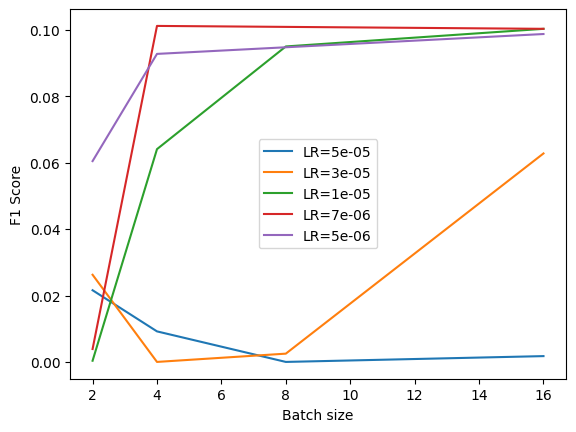

In [ ]:
# Extract unique learning rates from the DataFrame
learning_rates = robertabase_hyperparam_subset01['learning_rate'].unique()

# Plot the results
for lr in learning_rates:
    temp_df = robertabase_hyperparam_subset01[robertabase_hyperparam_subset01['learning_rate'] == lr]

    # Sort temp_df by 'train_batch_size' before plotting
    temp_df = temp_df.sort_values(by='train_batch_size')

    plt.plot(temp_df['train_batch_size'], temp_df['f1_score'], label=f'LR={lr}')

plt.xlabel('Batch size')
plt.ylabel('F1 Score')
plt.legend()
plt.show()

In [ ]:
robertabase_hyperparam_subset01

,learning_rate,train_batch_size,f1_score
0,0.000050,4.0,0.009195
1,0.000050,8.0,0.000000
2,0.000050,16.0,0.001750
3,0.000030,4.0,0.000000
4,0.000030,8.0,0.002492
5,0.000030,16.0,0.062774
6,0.000010,4.0,0.064070
7,0.000010,8.0,0.094992
8,0.000010,16.0,0.100298
9,0.000050,2.0,0.021584


##5%

In [ ]:
# Create a DataFrame to store the results
robertabase_hyperparam_subset05 = pd.DataFrame(columns=['learning_rate', 'train_batch_size', 'f1_score'])

In [ ]:
# Create a DataFrame to store the results
robertabase_hyperparam_subset05 = pd.read_csv('/content/gdrive/My Drive/MSc Project/robertabase_hyperparam_subset05.csv')

In [ ]:
# Define the hyperparameters for tuning
HYPERPARAMETERS_TO_TUNE = {
    'learning_rate': [5e-5],
    'train_batch_size': [2],
}

# Select only the "original" dataset
dataset_key = "original_subset05"
dataset = all_datasets[dataset_key]

# Iterate over all combinations of hyperparameters
for lr in HYPERPARAMETERS_TO_TUNE['learning_rate']:
    for batch_size in HYPERPARAMETERS_TO_TUNE['train_batch_size']:
        # Call the function for each combination of hyperparameters
        result = train_and_evaluate_model(dataset, dataset_key, lr, batch_size)

        # Append results to the DataFrame
        robertabase_hyperparam_subset05 = robertabase_hyperparam_subset05.append({
            'learning_rate': lr,
            'train_batch_size': batch_size,
            'f1_score': result['eval_f1'],
        }, ignore_index=True)

        robertabase_hyperparam_subset05.to_csv('/content/gdrive/My Drive/MSc Project/robertabase_hyperparam_subset05.csv', index=False)

        # Remove the folder after processing
        folder_path = f"/content/roberta-finetuned-{dataset_key}-lr-{lr}-batch-{batch_size}"
        !rm -r $folder_path

Training with original_subset05 data and lr 5e-05, batch_size 2...


Map:   0%|          | 0/380 [00:00<?, ? examples/s]

Map:   0%|          | 0/3173 [00:00<?, ? examples/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.out_proj.weight', 'classifier.out_proj.bias', 'classifier.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,F1,Roc Auc,Accuracy
1,No log,0.157011,0.000000,0.500000,0.000000
2,No log,0.150953,0.000000,0.500000,0.000000
3,0.184000,0.149778,0.000000,0.500000,0.000000
4,0.184000,0.148369,0.000000,0.500000,0.000000
5,0.184000,0.155997,0.000000,0.500000,0.000000
6,0.154900,0.141991,0.000000,0.500000,0.000000
7,0.154900,0.142771,0.092632,0.524206,0.023637
8,0.147400,0.139748,0.054348,0.513709,0.007564
9,0.147400,0.138845,0.074406,0.519099,0.016388
10,0.147400,0.138893,0.059490,0.515076,0.010400


Results with original_subset05: {'eval_loss': 0.1427706927061081, 'eval_f1': 0.09263157894736841, 'eval_roc_auc': 0.5242057011766242, 'eval_accuracy': 0.02363693665300977, 'eval_runtime': 25.715, 'eval_samples_per_second': 123.391, 'eval_steps_per_second': 61.715, 'epoch': 10.0}


<ipython-input-60-1d534e6da651>:18: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  robertabase_hyperparam_subset05 = robertabase_hyperparam_subset05.append({


In [ ]:
# Print out the best hyperparameters
best_hyperparams = robertabase_hyperparam_subset05.loc[robertabase_hyperparam_subset05['f1_score'].idxmax()]
print(f"Best hyperparameters for roberta-base-uncased model:\n{best_hyperparams}")

Best hyperparameters for roberta-base-uncased model:
learning_rate       0.000040
train_batch_size    2.000000
f1_score            0.596499
Name: 9, dtype: float64


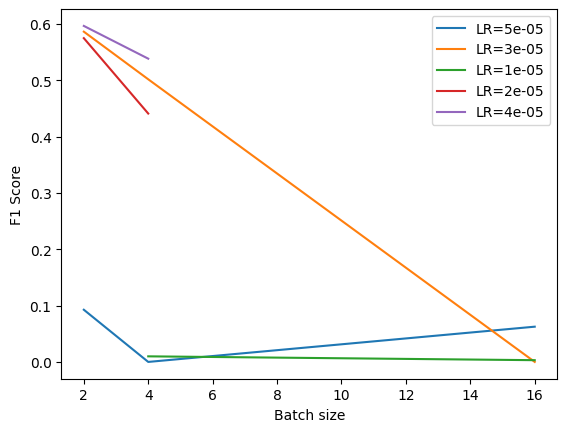

In [ ]:
# Extract unique learning rates from the DataFrame
learning_rates = robertabase_hyperparam_subset05['learning_rate'].unique()

# Plot the results
for lr in learning_rates:
    temp_df = robertabase_hyperparam_subset05[robertabase_hyperparam_subset05['learning_rate'] == lr]

    # Sort temp_df by 'train_batch_size' before plotting
    temp_df = temp_df.sort_values(by='train_batch_size')

    plt.plot(temp_df['train_batch_size'], temp_df['f1_score'], label=f'LR={lr}')

plt.xlabel('Batch size')
plt.ylabel('F1 Score')
plt.legend()
plt.show()

In [ ]:
robertabase_hyperparam_subset05

,learning_rate,train_batch_size,f1_score
0,0.00005,4.0,0.000000
1,0.00005,16.0,0.062563
2,0.00003,4.0,0.501753
3,0.00003,16.0,0.000000
4,0.00001,4.0,0.009910
5,0.00001,16.0,0.003089
6,0.00003,2.0,0.586288
7,0.00002,2.0,0.574778
8,0.00002,4.0,0.440933
9,0.00004,2.0,0.596499


##10%

In [ ]:
# Create a DataFrame to store the results
robertabase_hyperparam_subset10 = pd.DataFrame(columns=['learning_rate', 'train_batch_size', 'f1_score'])

In [ ]:
# Create a DataFrame to store the results
robertabase_hyperparam_subset10 = pd.read_csv('/content/gdrive/My Drive/MSc Project/robertabase_hyperparam_subset10.csv')

In [ ]:
# Define the hyperparameters for tuning
HYPERPARAMETERS_TO_TUNE = {
    'learning_rate': [3e-5, 5e-5, 6e-5],
    'train_batch_size': [2],
}

# Select only the "original" dataset
dataset_key = "original_subset10"
dataset = all_datasets[dataset_key]

# Iterate over all combinations of hyperparameters
for lr in HYPERPARAMETERS_TO_TUNE['learning_rate']:
    for batch_size in HYPERPARAMETERS_TO_TUNE['train_batch_size']:
        # Call the function for each combination of hyperparameters
        result = train_and_evaluate_model(dataset, dataset_key, lr, batch_size)

        # Append results to the DataFrame
        robertabase_hyperparam_subset10 = robertabase_hyperparam_subset10.append({
            'learning_rate': lr,
            'train_batch_size': batch_size,
            'f1_score': result['eval_f1'],
        }, ignore_index=True)

        robertabase_hyperparam_subset10.to_csv('/content/gdrive/My Drive/MSc Project/robertabase_hyperparam_subset10.csv', index=False)

        # Remove the folder after processing
        folder_path = f"/content/roberta-finetuned-{dataset_key}-lr-{lr}-batch-{batch_size}"
        !rm -r $folder_path

Training with original_subset10 data and lr 3e-05, batch_size 2...


Map:   0%|          | 0/750 [00:00<?, ? examples/s]

Map:   0%|          | 0/3173 [00:00<?, ? examples/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.out_proj.weight', 'classifier.out_proj.bias', 'classifier.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,F1,Roc Auc,Accuracy
1,No log,0.152764,0.000000,0.500000,0.000000
2,0.191000,0.120591,0.433276,0.645577,0.209581
3,0.123400,0.107815,0.540894,0.700463,0.273243
4,0.101600,0.097590,0.596143,0.735314,0.323668
5,0.101600,0.090959,0.656928,0.776950,0.384179
6,0.079800,0.086688,0.644179,0.759620,0.372833
7,0.066700,0.085126,0.655886,0.774886,0.386070
8,0.056800,0.083121,0.678861,0.790811,0.413804
9,0.056800,0.082450,0.677476,0.788875,0.410968
10,0.050400,0.082063,0.678461,0.788859,0.410652


...

Map:   0%|          | 0/3173 [00:00<?, ? examples/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.out_proj.weight', 'classifier.out_proj.bias', 'classifier.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,F1,Roc Auc,Accuracy
1,No log,0.154826,0.000000,0.500000,0.000000
2,0.176300,0.153796,0.000000,0.500000,0.000000
3,0.155300,0.153117,0.000000,0.500000,0.000000
4,0.157500,0.153015,0.000000,0.500000,0.000000
5,0.157500,0.152942,0.000000,0.500000,0.000000
6,0.156300,0.152965,0.000000,0.500000,0.000000
7,0.155400,0.152714,0.000000,0.500000,0.000000
8,0.155200,0.152575,0.000000,0.500000,0.000000
9,0.155200,0.152579,0.000000,0.500000,0.000000
10,0.155400,0.152615,0.000000,0.500000,0.000000


Results with original_subset10: {'eval_loss': 0.15482577681541443, 'eval_f1': 0.0, 'eval_roc_auc': 0.5, 'eval_accuracy': 0.0, 'eval_runtime': 25.8938, 'eval_samples_per_second': 122.539, 'eval_steps_per_second': 61.289, 'epoch': 10.0}


<ipython-input-82-9c3009f0747d>:18: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  robertabase_hyperparam_subset10 = robertabase_hyperparam_subset10.append({


In [ ]:
# Print out the best hyperparameters
best_hyperparams = robertabase_hyperparam_subset10.loc[robertabase_hyperparam_subset10['f1_score'].idxmax()]
print(f"Best hyperparameters for roberta-base-uncased model:\n{best_hyperparams}")

Best hyperparameters for roberta-base-uncased model:
learning_rate       0.000030
train_batch_size    2.000000
f1_score            0.678861
Name: 9, dtype: float64


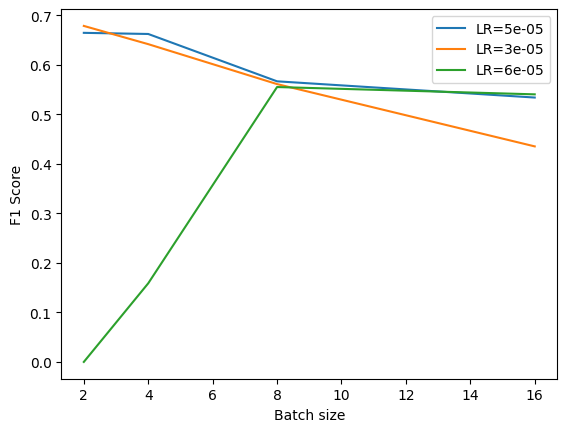

In [ ]:
# Extract unique learning rates from the DataFrame
learning_rates = robertabase_hyperparam_subset10['learning_rate'].unique()

# Plot the results
for lr in learning_rates:
    temp_df = robertabase_hyperparam_subset10[robertabase_hyperparam_subset10['learning_rate'] == lr]

    # Sort temp_df by 'train_batch_size' before plotting
    temp_df = temp_df.sort_values(by='train_batch_size')

    plt.plot(temp_df['train_batch_size'], temp_df['f1_score'], label=f'LR={lr}')

plt.xlabel('Batch size')
plt.ylabel('F1 Score')
plt.legend()
plt.show()

In [ ]:
robertabase_hyperparam_subset10

,learning_rate,train_batch_size,f1_score
0,0.00005,4.0,0.662581
1,0.00005,8.0,0.566936
2,0.00005,16.0,0.534154
3,0.00003,4.0,0.642021
4,0.00003,8.0,0.561315
5,0.00003,16.0,0.435462
6,0.00006,4.0,0.158846
7,0.00006,8.0,0.555392
8,0.00006,16.0,0.540621
9,0.00003,2.0,0.678861


##20%

In [ ]:
# Create a DataFrame to store the results
robertabase_hyperparam_subset20 = pd.DataFrame(columns=['learning_rate', 'train_batch_size', 'f1_score'])

In [ ]:
# Create a DataFrame to store the results
robertabase_hyperparam_subset20 = pd.read_csv('/content/gdrive/My Drive/MSc Project/robertabase_hyperparam_subset20.csv')

In [ ]:
# Define the hyperparameters for tuning
HYPERPARAMETERS_TO_TUNE = {
    'learning_rate': [5e-5, 6e-5],
    'train_batch_size': [16],
}

# Select only the "original" dataset
dataset_key = "original_subset20"
dataset = all_datasets[dataset_key]

# Iterate over all combinations of hyperparameters
for lr in HYPERPARAMETERS_TO_TUNE['learning_rate']:
    for batch_size in HYPERPARAMETERS_TO_TUNE['train_batch_size']:
        # Call the function for each combination of hyperparameters
        result = train_and_evaluate_model(dataset, dataset_key, lr, batch_size)

        # Append results to the DataFrame
        robertabase_hyperparam_subset20 = robertabase_hyperparam_subset20.append({
            'learning_rate': lr,
            'train_batch_size': batch_size,
            'f1_score': result['eval_f1'],
        }, ignore_index=True)

        robertabase_hyperparam_subset20.to_csv('/content/gdrive/My Drive/MSc Project/robertabase_hyperparam_subset20.csv', index=False)

        # Remove the folder after processing
        folder_path = f"/content/roberta-finetuned-{dataset_key}-lr-{lr}-batch-{batch_size}"
        !rm -r $folder_path

Training with original_subset20 data and lr 5e-05, batch_size 16...


Map:   0%|          | 0/1517 [00:00<?, ? examples/s]

Map:   0%|          | 0/3173 [00:00<?, ? examples/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.out_proj.weight', 'classifier.dense.bias', 'classifier.out_proj.bias', 'classifier.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,F1,Roc Auc,Accuracy
1,No log,0.160201,0.000000,0.500000,0.000000
2,No log,0.139485,0.197344,0.555929,0.037189
3,No log,0.119639,0.501642,0.687173,0.240466
4,No log,0.112389,0.513419,0.692702,0.271352
5,No log,0.104739,0.564511,0.723624,0.291207
6,0.145100,0.099970,0.576914,0.726932,0.299086
7,0.145100,0.095469,0.607084,0.743449,0.335645
8,0.145100,0.092284,0.629417,0.756338,0.341948
9,0.145100,0.090428,0.648136,0.767995,0.375039
10,0.145100,0.089471,0.646926,0.765686,0.373148


...

Map:   0%|          | 0/3173 [00:00<?, ? examples/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.out_proj.weight', 'classifier.dense.bias', 'classifier.out_proj.bias', 'classifier.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,F1,Roc Auc,Accuracy
1,No log,0.157351,0.000000,0.500000,0.000000
2,No log,0.139802,0.037736,0.509436,0.004727
3,No log,0.130605,0.174109,0.549496,0.016388
4,No log,0.122158,0.386052,0.634222,0.128900
5,No log,0.114365,0.483569,0.684211,0.211787
6,0.147600,0.107046,0.525997,0.697917,0.267885
7,0.147600,0.102631,0.545866,0.711201,0.276710
8,0.147600,0.098158,0.568092,0.720162,0.294359
9,0.147600,0.096572,0.581578,0.728120,0.308856
10,0.147600,0.094864,0.596304,0.735638,0.322723


Results with original_subset20: {'eval_loss': 0.09486377239227295, 'eval_f1': 0.5963037185482075, 'eval_roc_auc': 0.735638253710825, 'eval_accuracy': 0.3227229751024267, 'eval_runtime': 7.4195, 'eval_samples_per_second': 427.66, 'eval_steps_per_second': 26.821, 'epoch': 10.0}


<ipython-input-19-53bdedf5300e>:18: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  robertabase_hyperparam_subset20 = robertabase_hyperparam_subset20.append({


In [ ]:
# Print out the best hyperparameters
best_hyperparams = robertabase_hyperparam_subset20.loc[robertabase_hyperparam_subset20['f1_score'].idxmax()]
print(f"Best hyperparameters for roberta-base-uncased model:\n{best_hyperparams}")

Best hyperparameters for roberta-base-uncased model:
learning_rate       0.000030
train_batch_size    2.000000
f1_score            0.731944
Name: 0, dtype: float64


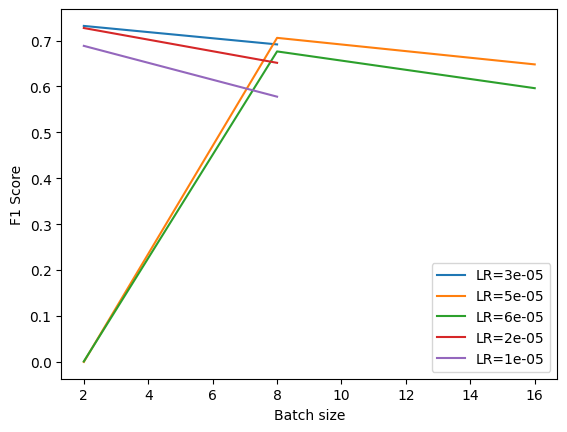

In [ ]:
# Extract unique learning rates from the DataFrame
learning_rates = robertabase_hyperparam_subset20['learning_rate'].unique()

# Plot the results
for lr in learning_rates:
    temp_df = robertabase_hyperparam_subset20[robertabase_hyperparam_subset20['learning_rate'] == lr]

    # Sort temp_df by 'train_batch_size' before plotting
    temp_df = temp_df.sort_values(by='train_batch_size')

    plt.plot(temp_df['train_batch_size'], temp_df['f1_score'], label=f'LR={lr}')

plt.xlabel('Batch size')
plt.ylabel('F1 Score')
plt.legend()
plt.show()

In [ ]:
robertabase_hyperparam_subset20

,learning_rate,train_batch_size,f1_score
0,0.00003,2.0,0.731944
1,0.00005,2.0,0.000000
2,0.00006,2.0,0.001070
3,0.00003,8.0,0.691663
4,0.00005,8.0,0.705942
5,0.00006,8.0,0.676393
6,0.00002,2.0,0.727379
7,0.00002,8.0,0.651565
8,0.00001,2.0,0.688501
9,0.00001,8.0,0.577828


##30%

In [ ]:
# Create a DataFrame to store the results
robertabase_hyperparam_subset30 = pd.DataFrame(columns=['learning_rate', 'train_batch_size', 'f1_score'])

In [ ]:
# Create a DataFrame to store the results
robertabase_hyperparam_subset30 = pd.read_csv('/content/gdrive/My Drive/MSc Project/robertabase_hyperparam_subset30.csv')

In [ ]:
# Define the hyperparameters for tuning
HYPERPARAMETERS_TO_TUNE = {
    'learning_rate': [2e-5, 3e-5, 5e-5],
    'train_batch_size': [2],
}

# Select only the "original" dataset
dataset_key = "original_subset30"
dataset = all_datasets[dataset_key]

# Iterate over all combinations of hyperparameters
for lr in HYPERPARAMETERS_TO_TUNE['learning_rate']:
    for batch_size in HYPERPARAMETERS_TO_TUNE['train_batch_size']:
        # Call the function for each combination of hyperparameters
        result = train_and_evaluate_model(dataset, dataset_key, lr, batch_size)

        # Append results to the DataFrame
        robertabase_hyperparam_subset30 = robertabase_hyperparam_subset30.append({
            'learning_rate': lr,
            'train_batch_size': batch_size,
            'f1_score': result['eval_f1'],
        }, ignore_index=True)

        robertabase_hyperparam_subset30.to_csv('/content/gdrive/My Drive/MSc Project/robertabase_hyperparam_subset30.csv', index=False)

        # Remove the folder after processing
        folder_path = f"/content/roberta-finetuned-{dataset_key}-lr-{lr}-batch-{batch_size}"
        !rm -r $folder_path

Training with original_subset30 data and lr 2e-05, batch_size 2...


Map:   0%|          | 0/2247 [00:00<?, ? examples/s]

Map:   0%|          | 0/3173 [00:00<?, ? examples/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.out_proj.weight', 'classifier.dense.bias', 'classifier.out_proj.bias', 'classifier.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,F1,Roc Auc,Accuracy
1,0.126800,0.115282,0.528417,0.703673,0.270091
2,0.100700,0.094088,0.631050,0.759696,0.364324
3,0.079900,0.081611,0.674631,0.783798,0.419477
4,0.068200,0.077177,0.705752,0.808183,0.451623
5,0.053100,0.073709,0.729048,0.831880,0.484084
6,0.043500,0.072083,0.736913,0.837104,0.489127
7,0.036100,0.070848,0.739737,0.834358,0.495745
8,0.032000,0.071111,0.744758,0.843959,0.502679
9,0.029000,0.070652,0.749068,0.845134,0.506461
10,0.027400,0.070731,0.752325,0.849094,0.507091


...

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.out_proj.weight', 'classifier.dense.bias', 'classifier.out_proj.bias', 'classifier.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,F1,Roc Auc,Accuracy
1,0.126000,0.118803,0.489687,0.683365,0.245824
2,0.105800,0.100956,0.576314,0.736928,0.315474
3,0.083600,0.088358,0.629108,0.759167,0.376930
4,0.072600,0.085671,0.671601,0.809227,0.429247
5,0.057500,0.082413,0.696252,0.826656,0.436495
6,0.047700,0.074487,0.720670,0.828896,0.474945
7,0.038800,0.073569,0.727220,0.829489,0.476836
8,0.032300,0.073182,0.738254,0.841420,0.493854
9,0.027500,0.073701,0.744013,0.850832,0.501418


Epoch,Training Loss,Validation Loss,F1,Roc Auc,Accuracy
1,0.126000,0.118803,0.489687,0.683365,0.245824
2,0.105800,0.100956,0.576314,0.736928,0.315474
3,0.083600,0.088358,0.629108,0.759167,0.376930
4,0.072600,0.085671,0.671601,0.809227,0.429247
5,0.057500,0.082413,0.696252,0.826656,0.436495
6,0.047700,0.074487,0.720670,0.828896,0.474945
7,0.038800,0.073569,0.727220,0.829489,0.476836
8,0.032300,0.073182,0.738254,0.841420,0.493854
9,0.027500,0.073701,0.744013,0.850832,0.501418
10,0.025200,0.074115,0.744977,0.850407,0.504255


Results with original_subset30: {'eval_loss': 0.07411520183086395, 'eval_f1': 0.7449771049434633, 'eval_roc_auc': 0.8504070924280626, 'eval_accuracy': 0.5042546485975418, 'eval_runtime': 26.7799, 'eval_samples_per_second': 118.484, 'eval_steps_per_second': 59.261, 'epoch': 10.0}


<ipython-input-34-9c0a844ed4ad>:18: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  robertabase_hyperparam_subset30 = robertabase_hyperparam_subset30.append({


In [ ]:
# Print out the best hyperparameters
best_hyperparams = robertabase_hyperparam_subset30.loc[robertabase_hyperparam_subset30['f1_score'].idxmax()]
print(f"Best hyperparameters for roberta-base-uncased model:\n{best_hyperparams}")

Best hyperparameters for roberta-base-uncased model:
learning_rate       0.000030
train_batch_size    2.000000
f1_score            0.766051
Name: 11, dtype: float64


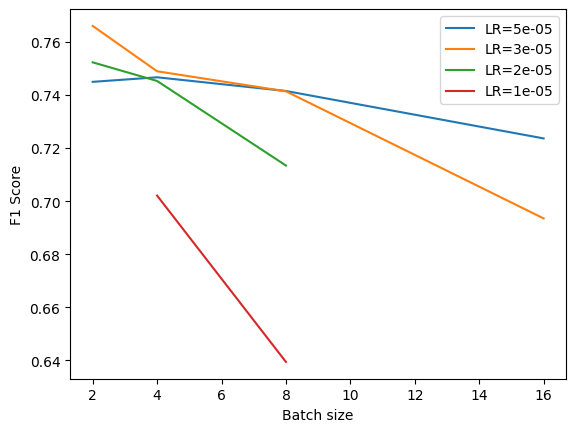

In [ ]:
# Extract unique learning rates from the DataFrame
learning_rates = robertabase_hyperparam_subset30['learning_rate'].unique()

# Plot the results
for lr in learning_rates:
    temp_df = robertabase_hyperparam_subset30[robertabase_hyperparam_subset30['learning_rate'] == lr]

    # Sort temp_df by 'train_batch_size' before plotting
    temp_df = temp_df.sort_values(by='train_batch_size')

    plt.plot(temp_df['train_batch_size'], temp_df['f1_score'], label=f'LR={lr}')

plt.xlabel('Batch size')
plt.ylabel('F1 Score')
plt.legend()
plt.show()

In [ ]:
robertabase_hyperparam_subset30

,learning_rate,train_batch_size,f1_score
0,0.00005,4.0,0.746692
1,0.00005,8.0,0.741530
2,0.00005,16.0,0.723658
3,0.00003,4.0,0.748958
4,0.00003,8.0,0.741409
5,0.00003,16.0,0.693509
6,0.00002,4.0,0.745303
7,0.00002,8.0,0.713436
8,0.00001,4.0,0.702106
9,0.00001,8.0,0.639426


## Roberta-large

In [ ]:
# Preprocess data
tokenizer = RobertaTokenizerFast.from_pretrained("roberta-large")

def preprocess_data(examples):
    text = examples["text"]
    encoding = tokenizer(text, padding="max_length", truncation=True, max_length=128)

    labels_batch = examples["labels"]
    labels_matrix = np.zeros((len(text), len(labels)))

    for i, label_list in enumerate(labels_batch):
        for label in label_list:
            idx = label2id[label]
            labels_matrix[i, idx] = 1

    encoding["labels"] = labels_matrix.tolist()

    return encoding

# Define metrics
def multi_label_metrics(predictions, labels, threshold=0.5):
    sigmoid = torch.nn.Sigmoid()
    probs = sigmoid(torch.Tensor(predictions))
    y_pred = np.zeros(probs.shape)
    y_pred[np.where(probs >= threshold)] = 1
    y_true = labels
    f1_micro_average = f1_score(y_true=y_true, y_pred=y_pred, average='micro')
    roc_auc = roc_auc_score(y_true, y_pred, average='micro')
    accuracy = accuracy_score(y_true, y_pred)
    metrics = {'f1': f1_micro_average,
               'roc_auc': roc_auc,
               'accuracy': accuracy}
    return metrics

def compute_metrics(p: EvalPrediction):
    preds = p.predictions[0] if isinstance(p.predictions, tuple) else p.predictions
    result = multi_label_metrics(predictions=preds, labels=p.label_ids)
    return result



# Function to train and evaluate the model for a given augmented dataset
def train_and_evaluate_model(dataset, dataset_key, lr, batch_size):
    print(f"Training with {dataset_key} data and lr {lr}, batch_size {batch_size}...")

    # Apply preprocessing
    encoded_dataset = dataset.map(preprocess_data, batched=True, remove_columns=['text', 'labels'])

    # Set format to PyTorch tensors
    encoded_dataset.set_format("torch")

    # Define the model
    model = RobertaForSequenceClassification.from_pretrained("roberta-large", num_labels=len(labels))

    # Training arguments
    training_args = TrainingArguments(
        output_dir=f"robertalarge-finetuned-{dataset_key}-lr-{lr}-batch-{batch_size}",
        evaluation_strategy="epoch",
        save_strategy="epoch",
        learning_rate=lr,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        num_train_epochs=10,
        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model="f1",
    )
    # Define the trainer
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=encoded_dataset["train"],
        eval_dataset=encoded_dataset["validation"],
        tokenizer=tokenizer,
        compute_metrics=compute_metrics,
    )
    # Start training
    trainer.train()
    # Evaluate the model
    result = trainer.evaluate()
    print(f"Results with {dataset_key}: {result}")
    return result

##1%

In [ ]:
# Create a DataFrame to store the results
robertalarge_hyperparam_subset01 = pd.DataFrame(columns=['learning_rate', 'train_batch_size', 'f1_score'])

In [ ]:
# Create a DataFrame to store the results
robertalarge_hyperparam_subset01 = pd.read_csv('/content/gdrive/My Drive/MSc Project/robertalarge_hyperparam_subset01.csv')

In [ ]:
# Define the hyperparameters for tuning
HYPERPARAMETERS_TO_TUNE = {
    'learning_rate': [1e-5, 2e-5],
    'train_batch_size': [2],
}

# Select only the "original" dataset
dataset_key = "original_subset01"
dataset = all_datasets[dataset_key]

# Iterate over all combinations of hyperparameters
for lr in HYPERPARAMETERS_TO_TUNE['learning_rate']:
    for batch_size in HYPERPARAMETERS_TO_TUNE['train_batch_size']:
        # Call the function for each combination of hyperparameters
        result = train_and_evaluate_model(dataset, dataset_key, lr, batch_size)

        # Append results to the DataFrame
        robertalarge_hyperparam_subset01 = robertalarge_hyperparam_subset01.append({
            'learning_rate': lr,
            'train_batch_size': batch_size,
            'f1_score': result['eval_f1'],
        }, ignore_index=True)

        # Save the DataFrame to the CSV file
        robertalarge_hyperparam_subset01.to_csv('/content/gdrive/My Drive/MSc Project/robertalarge_hyperparam_subset01.csv', index=False)

        # Remove the folder after processing
        folder_path = f"/content/robertalarge-finetuned-{dataset_key}-lr-{lr}-batch-{batch_size}"
        !rm -r $folder_path

Training with original_subset01 data and lr 1e-05, batch_size 2...


Map:   0%|          | 0/88 [00:00<?, ? examples/s]

Map:   0%|          | 0/3173 [00:00<?, ? examples/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-large and are newly initialized: ['classifier.out_proj.bias', 'classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,F1,Roc Auc,Accuracy
1,No log,0.393290,0.004968,0.497657,0.000630
2,No log,0.228874,0.000000,0.500000,0.000000
3,No log,0.193308,0.000000,0.500000,0.000000
4,No log,0.182405,0.000000,0.500000,0.000000
5,No log,0.174973,0.000000,0.500000,0.000000
6,No log,0.170446,0.000000,0.500000,0.000000
7,No log,0.165396,0.000000,0.500000,0.000000
8,No log,0.161823,0.004620,0.501118,0.000630
9,No log,0.159895,0.054827,0.513872,0.010400
10,No log,0.159066,0.023835,0.505918,0.003152


...

Map:   0%|          | 0/3173 [00:00<?, ? examples/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-large and are newly initialized: ['classifier.out_proj.bias', 'classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,F1,Roc Auc,Accuracy
1,No log,0.227397,0.000000,0.500000,0.000000
2,No log,0.177224,0.000000,0.500000,0.000000
3,No log,0.166656,0.000000,0.500000,0.000000
4,No log,0.161941,0.000000,0.500000,0.000000
5,No log,0.158647,0.000000,0.500000,0.000000
6,No log,0.151588,0.023431,0.505764,0.004727
7,No log,0.145919,0.074336,0.519163,0.011661
8,No log,0.141887,0.184085,0.551987,0.045068
9,No log,0.140141,0.284176,0.587386,0.095808
10,No log,0.139460,0.273766,0.582721,0.089505


Results with original_subset01: {'eval_loss': 0.14014120399951935, 'eval_f1': 0.28417622892761013, 'eval_roc_auc': 0.5873863202842171, 'eval_accuracy': 0.09580838323353294, 'eval_runtime': 36.4758, 'eval_samples_per_second': 86.989, 'eval_steps_per_second': 43.508, 'epoch': 10.0}


<ipython-input-18-31f67176d512>:18: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  robertalarge_hyperparam_subset01 = robertalarge_hyperparam_subset01.append({


In [ ]:
# Print out the best hyperparameters
best_hyperparams = robertalarge_hyperparam_subset01.loc[robertalarge_hyperparam_subset01['f1_score'].idxmax()]
print(f"Best hyperparameters for roberta-large-uncased model:\n{best_hyperparams}")

Best hyperparameters for roberta-large-uncased model:
learning_rate       0.000030
train_batch_size    2.000000
f1_score            0.427961
Name: 6, dtype: float64


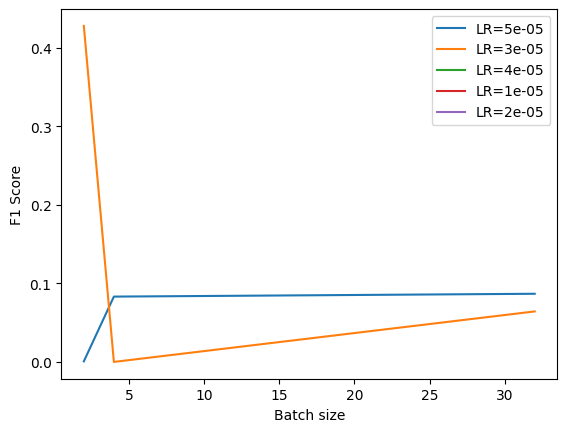

In [ ]:
# Extract unique learning rates from the DataFrame
learning_rates = robertalarge_hyperparam_subset01['learning_rate'].unique()

# Plot the results
for lr in learning_rates:
    temp_df = robertalarge_hyperparam_subset01[robertalarge_hyperparam_subset01['learning_rate'] == lr]

    # Sort temp_df by 'train_batch_size' before plotting
    temp_df = temp_df.sort_values(by='train_batch_size')

    plt.plot(temp_df['train_batch_size'], temp_df['f1_score'], label=f'LR={lr}')

plt.xlabel('Batch size')
plt.ylabel('F1 Score')
plt.legend()
plt.show()

In [ ]:
robertalarge_hyperparam_subset01

,learning_rate,train_batch_size,f1_score
0,0.00005,4.0,0.083197
1,0.00005,32.0,0.086800
2,0.00003,4.0,0.000000
3,0.00003,32.0,0.064313
4,0.00005,2.0,0.000713
5,0.00004,2.0,0.396906
6,0.00003,2.0,0.427961
7,0.00001,2.0,0.054827
8,0.00002,2.0,0.284176


##5%

In [ ]:
# Create a DataFrame to store the results
robertalarge_hyperparam_subset05 = pd.DataFrame(columns=['learning_rate', 'train_batch_size', 'f1_score'])

In [ ]:
# Create a DataFrame to store the results
robertalarge_hyperparam_subset05 = pd.read_csv('/content/gdrive/My Drive/MSc Project/robertalarge_hyperparam_subset05.csv')

In [ ]:
# Define the hyperparameters for tuning
HYPERPARAMETERS_TO_TUNE = {
    'learning_rate': [2e-5, 3e-5, 5e-5],
    'train_batch_size': [16],
}

# Select only the "original" dataset
dataset_key = "original_subset05"
dataset = all_datasets[dataset_key]

# Iterate over all combinations of hyperparameters
for lr in HYPERPARAMETERS_TO_TUNE['learning_rate']:
    for batch_size in HYPERPARAMETERS_TO_TUNE['train_batch_size']:
        # Call the function for each combination of hyperparameters
        result = train_and_evaluate_model(dataset, dataset_key, lr, batch_size)

        # Append results to the DataFrame
        robertalarge_hyperparam_subset05 = robertalarge_hyperparam_subset05.append({
            'learning_rate': lr,
            'train_batch_size': batch_size,
            'f1_score': result['eval_f1'],
        }, ignore_index=True)

        # Save the DataFrame to the CSV file
        robertalarge_hyperparam_subset05.to_csv('/content/gdrive/My Drive/MSc Project/robertalarge_hyperparam_subset05.csv', index=False)

        # Remove the folder after processing
        folder_path = f"/content/robertalarge-finetuned-{dataset_key}-lr-{lr}-batch-{batch_size}"
        !rm -r $folder_path

Training with original_subset05 data and lr 2e-05, batch_size 16...


Map:   0%|          | 0/380 [00:00<?, ? examples/s]

Map:   0%|          | 0/3173 [00:00<?, ? examples/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-large and are newly initialized: ['classifier.out_proj.bias', 'classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,F1,Roc Auc,Accuracy
1,No log,0.256502,0.000000,0.500000,0.000000
2,No log,0.187398,0.000000,0.500000,0.000000
3,No log,0.171054,0.000000,0.500000,0.000000
4,No log,0.164666,0.000000,0.500000,0.000000
5,No log,0.161158,0.000000,0.500000,0.000000
6,No log,0.157849,0.000000,0.500000,0.000000
7,No log,0.150570,0.000000,0.500000,0.000000
8,No log,0.144391,0.000713,0.500178,0.000000
9,No log,0.140346,0.119294,0.531755,0.019855
10,No log,0.138975,0.166316,0.545563,0.032146


...

Map:   0%|          | 0/3173 [00:00<?, ? examples/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-large and are newly initialized: ['classifier.out_proj.bias', 'classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,F1,Roc Auc,Accuracy
1,No log,0.180786,0.000000,0.500000,0.000000
2,No log,0.159941,0.000000,0.500000,0.000000
3,No log,0.155890,0.000000,0.500000,0.000000
4,No log,0.151744,0.000000,0.500000,0.000000
5,No log,0.145463,0.000000,0.500000,0.000000
6,No log,0.137065,0.052758,0.513376,0.006303
7,No log,0.132933,0.165266,0.545649,0.031516
8,No log,0.127880,0.290109,0.589602,0.080366
9,No log,0.125146,0.363254,0.620402,0.126694
10,No log,0.124155,0.397720,0.636719,0.150331


Results with original_subset05: {'eval_loss': 0.12415487319231033, 'eval_f1': 0.3977200759974667, 'eval_roc_auc': 0.6367188982352551, 'eval_accuracy': 0.15033091711314214, 'eval_runtime': 21.9566, 'eval_samples_per_second': 144.512, 'eval_steps_per_second': 9.063, 'epoch': 10.0}


<ipython-input-33-c91d2124f7d3>:18: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  robertalarge_hyperparam_subset05 = robertalarge_hyperparam_subset05.append({


In [ ]:
# Print out the best hyperparameters
best_hyperparams = robertalarge_hyperparam_subset05.loc[robertalarge_hyperparam_subset05['f1_score'].idxmax()]
print(f"Best hyperparameters for roberta-large-uncased model:\n{best_hyperparams}")

Best hyperparameters for roberta-large-uncased model:
learning_rate       0.000020
train_batch_size    2.000000
f1_score            0.666805
Name: 4, dtype: float64


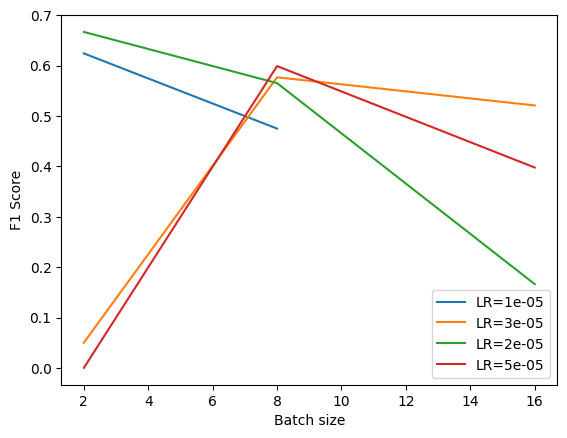

In [ ]:
# Extract unique learning rates from the DataFrame
learning_rates = robertalarge_hyperparam_subset05['learning_rate'].unique()

# Plot the results
for lr in learning_rates:
    temp_df = robertalarge_hyperparam_subset05[robertalarge_hyperparam_subset05['learning_rate'] == lr]

    # Sort temp_df by 'train_batch_size' before plotting
    temp_df = temp_df.sort_values(by='train_batch_size')

    plt.plot(temp_df['train_batch_size'], temp_df['f1_score'], label=f'LR={lr}')

plt.xlabel('Batch size')
plt.ylabel('F1 Score')
plt.legend()
plt.show()

In [ ]:
robertalarge_hyperparam_subset05

,learning_rate,train_batch_size,f1_score
0,0.00001,2.0,0.624212
1,0.00001,8.0,0.474931
2,0.00003,2.0,0.050085
3,0.00003,8.0,0.576778
4,0.00002,2.0,0.666805
5,0.00002,8.0,0.565202
6,0.00005,2.0,0.000000
7,0.00005,8.0,0.598978
8,0.00002,16.0,0.166316
9,0.00003,16.0,0.520918


##10%

In [ ]:
# Create a DataFrame to store the results
robertalarge_hyperparam_subset10 = pd.DataFrame(columns=['learning_rate', 'train_batch_size', 'f1_score'])

In [ ]:
# Create a DataFrame to store the results
robertalarge_hyperparam_subset10 = pd.read_csv('/content/gdrive/My Drive/MSc Project/robertalarge_hyperparam_subset10.csv')

In [ ]:
# Define the hyperparameters for tuning
HYPERPARAMETERS_TO_TUNE = {
    'learning_rate': [1e-5, 3e-5],
    'train_batch_size': [2],
}

# Select only the "original" dataset
dataset_key = "original_subset10"
dataset = all_datasets[dataset_key]

# Iterate over all combinations of hyperparameters
for lr in HYPERPARAMETERS_TO_TUNE['learning_rate']:
    for batch_size in HYPERPARAMETERS_TO_TUNE['train_batch_size']:
        # Call the function for each combination of hyperparameters
        result = train_and_evaluate_model(dataset, dataset_key, lr, batch_size)

        # Append results to the DataFrame
        robertalarge_hyperparam_subset10 = robertalarge_hyperparam_subset10.append({
            'learning_rate': lr,
            'train_batch_size': batch_size,
            'f1_score': result['eval_f1'],
        }, ignore_index=True)

        # Save the DataFrame to the CSV file
        robertalarge_hyperparam_subset10.to_csv('/content/gdrive/My Drive/MSc Project/robertalarge_hyperparam_subset10.csv', index=False)

        # Remove the folder after processing
        folder_path = f"/content/robertalarge-finetuned-{dataset_key}-lr-{lr}-batch-{batch_size}"
        !rm -r $folder_path

Training with original_subset10 data and lr 1e-05, batch_size 2...


Map:   0%|          | 0/750 [00:00<?, ? examples/s]

Map:   0%|          | 0/3173 [00:00<?, ? examples/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-large and are newly initialized: ['classifier.dense.weight', 'classifier.dense.bias', 'classifier.out_proj.weight', 'classifier.out_proj.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
You're using a RobertaTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


Epoch,Training Loss,Validation Loss,F1,Roc Auc,Accuracy
1,No log,0.144775,0.000000,0.500000,0.000000
2,0.200500,0.117325,0.419376,0.639314,0.192877
3,0.119600,0.103146,0.585234,0.729080,0.308541
4,0.096800,0.094313,0.634278,0.759202,0.359597
5,0.096800,0.087529,0.669314,0.782089,0.406870
6,0.076900,0.084573,0.666951,0.776413,0.404980
7,0.066000,0.082845,0.689718,0.798596,0.437126
8,0.057200,0.080169,0.704390,0.808176,0.449102
9,0.057200,0.079754,0.705481,0.809538,0.451308
10,0.051400,0.079152,0.707166,0.811182,0.457296


...

Map:   0%|          | 0/3173 [00:00<?, ? examples/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-large and are newly initialized: ['classifier.dense.weight', 'classifier.dense.bias', 'classifier.out_proj.weight', 'classifier.out_proj.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,F1,Roc Auc,Accuracy
1,No log,0.155478,0.000000,0.500000,0.000000
2,0.179600,0.154262,0.000000,0.500000,0.000000
3,0.154900,0.154521,0.000000,0.500000,0.000000
4,0.156600,0.156186,0.000000,0.500000,0.000000
5,0.156600,0.153369,0.000000,0.500000,0.000000
6,0.156000,0.155459,0.000000,0.500000,0.000000
7,0.151600,0.155500,0.000000,0.500000,0.000000
8,0.150900,0.158481,0.000000,0.500000,0.000000
9,0.150900,0.158749,0.000000,0.500000,0.000000
10,0.149600,0.158652,0.000000,0.500000,0.000000


Results with original_subset10: {'eval_loss': 0.1554783135652542, 'eval_f1': 0.0, 'eval_roc_auc': 0.5, 'eval_accuracy': 0.0, 'eval_runtime': 44.6049, 'eval_samples_per_second': 71.136, 'eval_steps_per_second': 35.579, 'epoch': 10.0}


<ipython-input-14-31d70f255896>:18: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  robertalarge_hyperparam_subset10 = robertalarge_hyperparam_subset10.append({


In [ ]:
# Print out the best hyperparameters
best_hyperparams = robertalarge_hyperparam_subset10.loc[robertalarge_hyperparam_subset10['f1_score'].idxmax()]
print(f"Best hyperparameters for roberta-large-uncased model:\n{best_hyperparams}")

Best hyperparameters for roberta-large-uncased model:
learning_rate       0.000030
train_batch_size    4.000000
f1_score            0.721435
Name: 2, dtype: float64


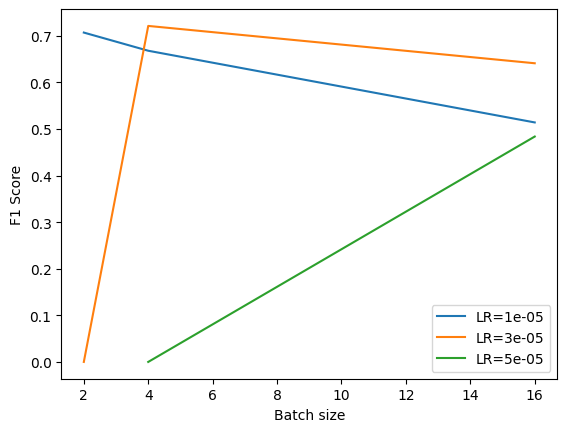

In [ ]:
# Extract unique learning rates from the DataFrame
learning_rates = robertalarge_hyperparam_subset10['learning_rate'].unique()

# Plot the results
for lr in learning_rates:
    temp_df = robertalarge_hyperparam_subset10[robertalarge_hyperparam_subset10['learning_rate'] == lr]

    # Sort temp_df by 'train_batch_size' before plotting
    temp_df = temp_df.sort_values(by='train_batch_size')

    plt.plot(temp_df['train_batch_size'], temp_df['f1_score'], label=f'LR={lr}')

plt.xlabel('Batch size')
plt.ylabel('F1 Score')
plt.legend()
plt.show()

In [ ]:
robertalarge_hyperparam_subset10

,learning_rate,train_batch_size,f1_score
0,0.00001,4.0,0.668140
1,0.00001,16.0,0.514210
2,0.00003,4.0,0.721435
3,0.00003,16.0,0.641261
4,0.00005,4.0,0.000000
5,0.00005,16.0,0.483895
6,0.00001,2.0,0.707166
7,0.00003,2.0,0.000000


##20%

In [ ]:
# Create a DataFrame to store the results
robertalarge_hyperparam_subset20 = pd.DataFrame(columns=['learning_rate', 'train_batch_size', 'f1_score'])

In [ ]:
# Create a DataFrame to store the results
robertalarge_hyperparam_subset20 = pd.read_csv('/content/gdrive/My Drive/MSc Project/robertalarge_hyperparam_subset20.csv')

In [ ]:
# Define the hyperparameters for tuning
HYPERPARAMETERS_TO_TUNE = {
    'learning_rate': [3e-5, 5e-5],
    'train_batch_size': [32],
}

# Select only the "original" dataset
dataset_key = "original_subset20"
dataset = all_datasets[dataset_key]

# Iterate over all combinations of hyperparameters
for lr in HYPERPARAMETERS_TO_TUNE['learning_rate']:
    for batch_size in HYPERPARAMETERS_TO_TUNE['train_batch_size']:
        # Call the function for each combination of hyperparameters
        result = train_and_evaluate_model(dataset, dataset_key, lr, batch_size)

        # Append results to the DataFrame
        robertalarge_hyperparam_subset20 = robertalarge_hyperparam_subset20.append({
            'learning_rate': lr,
            'train_batch_size': batch_size,
            'f1_score': result['eval_f1'],
        }, ignore_index=True)

        # Save the DataFrame to the CSV file
        robertalarge_hyperparam_subset20.to_csv('/content/gdrive/My Drive/MSc Project/robertalarge_hyperparam_subset20.csv', index=False)

        # Remove the folder after processing
        folder_path = f"/content/robertalarge-finetuned-{dataset_key}-lr-{lr}-batch-{batch_size}"
        !rm -r $folder_path

Training with original_subset20 data and lr 3e-05, batch_size 32...


Map:   0%|          | 0/1517 [00:00<?, ? examples/s]

Map:   0%|          | 0/3173 [00:00<?, ? examples/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-large and are newly initialized: ['classifier.dense.weight', 'classifier.dense.bias', 'classifier.out_proj.weight', 'classifier.out_proj.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,F1,Roc Auc,Accuracy
1,No log,0.168103,0.000000,0.500000,0.000000
2,No log,0.153378,0.000000,0.500000,0.000000
3,No log,0.133122,0.121736,0.532582,0.034668
4,No log,0.114577,0.507663,0.686202,0.232903
5,No log,0.103197,0.561424,0.715036,0.271982
6,No log,0.094836,0.631498,0.752914,0.351718
7,No log,0.090370,0.644109,0.758105,0.368106
8,No log,0.086477,0.674701,0.781559,0.403404
9,No log,0.085195,0.682245,0.788384,0.414434
10,No log,0.084663,0.688327,0.791588,0.426095


...

Map:   0%|          | 0/3173 [00:00<?, ? examples/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-large and are newly initialized: ['classifier.dense.weight', 'classifier.dense.bias', 'classifier.out_proj.weight', 'classifier.out_proj.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,F1,Roc Auc,Accuracy
1,No log,0.158701,0.000000,0.500000,0.000000
2,No log,0.149063,0.000000,0.500000,0.000000
3,No log,0.134679,0.164581,0.545717,0.029940
4,No log,0.120112,0.393135,0.639462,0.090766
5,No log,0.107218,0.555791,0.717951,0.279546
6,No log,0.099558,0.596538,0.737770,0.312953
7,No log,0.092484,0.622385,0.747878,0.342263
8,No log,0.087557,0.663210,0.776249,0.395525
9,No log,0.085310,0.680693,0.790691,0.415695
10,No log,0.083720,0.686862,0.791012,0.425150


Results with original_subset20: {'eval_loss': 0.08372040838003159, 'eval_f1': 0.6868623776806162, 'eval_roc_auc': 0.7910115296193911, 'eval_accuracy': 0.4251497005988024, 'eval_runtime': 21.3304, 'eval_samples_per_second': 148.755, 'eval_steps_per_second': 4.688, 'epoch': 10.0}


<ipython-input-23-362d9c61a8df>:18: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  robertalarge_hyperparam_subset20 = robertalarge_hyperparam_subset20.append({


In [ ]:
# Print out the best hyperparameters
best_hyperparams = robertalarge_hyperparam_subset20.loc[robertalarge_hyperparam_subset20['f1_score'].idxmax()]
print(f"Best hyperparameters for roberta-large-uncased model:\n{best_hyperparams}")

Best hyperparameters for roberta-large-uncased model:
learning_rate       0.000010
train_batch_size    2.000000
f1_score            0.758647
Name: 0, dtype: float64


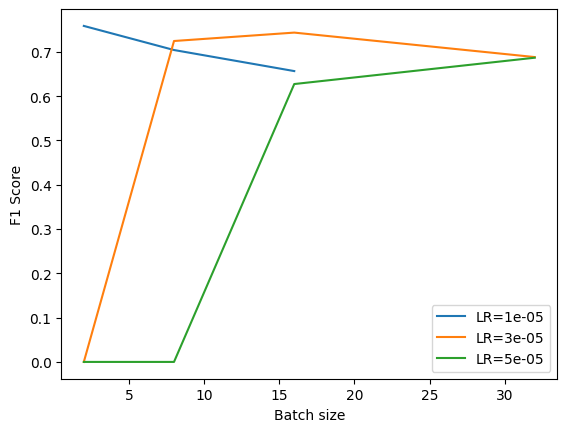

In [ ]:
# Extract unique learning rates from the DataFrame
learning_rates = robertalarge_hyperparam_subset20['learning_rate'].unique()

# Plot the results
for lr in learning_rates:
    temp_df = robertalarge_hyperparam_subset20[robertalarge_hyperparam_subset20['learning_rate'] == lr]

    # Sort temp_df by 'train_batch_size' before plotting
    temp_df = temp_df.sort_values(by='train_batch_size')

    plt.plot(temp_df['train_batch_size'], temp_df['f1_score'], label=f'LR={lr}')

plt.xlabel('Batch size')
plt.ylabel('F1 Score')
plt.legend()
plt.show()

In [ ]:
robertalarge_hyperparam_subset20

,learning_rate,train_batch_size,f1_score
0,0.00001,2.0,0.758647
1,0.00001,8.0,0.704228
2,0.00001,16.0,0.656687
3,0.00003,2.0,0.000000
4,0.00003,8.0,0.724589
5,0.00003,16.0,0.743567
6,0.00005,2.0,0.000000
7,0.00005,8.0,0.000000
8,0.00005,16.0,0.627426
9,0.00003,32.0,0.688327


##30%

In [ ]:
# Create a DataFrame to store the results
robertalarge_hyperparam_subset30 = pd.DataFrame(columns=['learning_rate', 'train_batch_size', 'f1_score'])

In [ ]:
# Create a DataFrame to store the results
robertalarge_hyperparam_subset30 = pd.read_csv('/content/gdrive/My Drive/MSc Project/robertalarge_hyperparam_subset30.csv')

In [ ]:
# Define the hyperparameters for tuning
HYPERPARAMETERS_TO_TUNE = {
    'learning_rate': [5e-5],
    'train_batch_size': [8, 16],
}

# Select only the "original" dataset
dataset_key = "original_subset30"
dataset = all_datasets[dataset_key]

# Iterate over all combinations of hyperparameters
for lr in HYPERPARAMETERS_TO_TUNE['learning_rate']:
    for batch_size in HYPERPARAMETERS_TO_TUNE['train_batch_size']:
        # Call the function for each combination of hyperparameters
        result = train_and_evaluate_model(dataset, dataset_key, lr, batch_size)

        # Append results to the DataFrame
        robertalarge_hyperparam_subset30 = robertalarge_hyperparam_subset30.append({
            'learning_rate': lr,
            'train_batch_size': batch_size,
            'f1_score': result['eval_f1'],
        }, ignore_index=True)

        # Save the DataFrame to the CSV file
        robertalarge_hyperparam_subset30.to_csv('/content/gdrive/My Drive/MSc Project/robertalarge_hyperparam_subset30.csv', index=False)

        # Remove the folder after processing
        folder_path = f"/content/robertalarge-finetuned-{dataset_key}-lr-{lr}-batch-{batch_size}"
        !rm -r $folder_path

Training with original_subset30 data and lr 5e-05, batch_size 8...


Map:   0%|          | 0/2247 [00:00<?, ? examples/s]

Map:   0%|          | 0/3173 [00:00<?, ? examples/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-large and are newly initialized: ['classifier.out_proj.weight', 'classifier.dense.bias', 'classifier.out_proj.bias', 'classifier.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
You're using a RobertaTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


Epoch,Training Loss,Validation Loss,F1,Roc Auc,Accuracy
1,No log,0.119767,0.475404,0.669303,0.226915
2,0.146800,0.096856,0.577935,0.723423,0.310117
3,0.146800,0.082551,0.679453,0.798714,0.411913
4,0.085600,0.078673,0.702296,0.812074,0.462023
5,0.085600,0.071302,0.725678,0.827685,0.470533
6,0.061500,0.068637,0.738538,0.840869,0.487236
7,0.061500,0.067322,0.746904,0.847601,0.494800
8,0.041600,0.066125,0.760521,0.857214,0.518752
9,0.028600,0.065889,0.762657,0.861274,0.512449
10,0.028600,0.066222,0.763876,0.862170,0.511818


...

Map:   0%|          | 0/3173 [00:00<?, ? examples/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-large and are newly initialized: ['classifier.out_proj.weight', 'classifier.dense.bias', 'classifier.out_proj.bias', 'classifier.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,F1,Roc Auc,Accuracy
1,No log,0.137906,0.141606,0.539303,0.018594
2,No log,0.112467,0.493789,0.682641,0.256540
3,No log,0.093972,0.627683,0.765320,0.382288
4,0.127300,0.083613,0.683815,0.800213,0.429877
5,0.127300,0.076781,0.695457,0.800822,0.449732
6,0.127300,0.074432,0.720712,0.824362,0.475260
7,0.127300,0.069715,0.744693,0.842897,0.501418
8,0.060300,0.067225,0.753367,0.852098,0.505830
9,0.060300,0.067200,0.757407,0.852440,0.513394
10,0.060300,0.067037,0.760685,0.855836,0.515916


Results with original_subset30: {'eval_loss': 0.06703739613294601, 'eval_f1': 0.7606853699868198, 'eval_roc_auc': 0.8558355755488174, 'eval_accuracy': 0.5159155373463599, 'eval_runtime': 22.5246, 'eval_samples_per_second': 140.868, 'eval_steps_per_second': 8.835, 'epoch': 10.0}


<ipython-input-19-176740f34565>:18: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  robertalarge_hyperparam_subset30 = robertalarge_hyperparam_subset30.append({


In [ ]:
# Print out the best hyperparameters
best_hyperparams = robertalarge_hyperparam_subset30.loc[robertalarge_hyperparam_subset30['f1_score'].idxmax()]
print(f"Best hyperparameters for roberta-large-uncased model:\n{best_hyperparams}")

Best hyperparameters for roberta-large-uncased model:
learning_rate        0.000030
train_batch_size    16.000000
f1_score             0.773043
Name: 2, dtype: float64


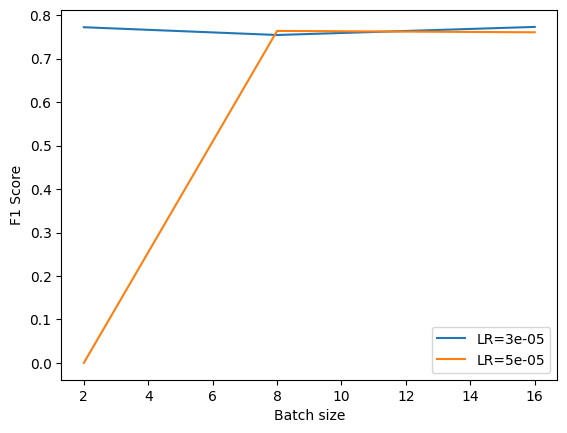

In [ ]:
# Extract unique learning rates from the DataFrame
learning_rates = robertalarge_hyperparam_subset30['learning_rate'].unique()

# Plot the results
for lr in learning_rates:
    temp_df = robertalarge_hyperparam_subset30[robertalarge_hyperparam_subset30['learning_rate'] == lr]

    # Sort temp_df by 'train_batch_size' before plotting
    temp_df = temp_df.sort_values(by='train_batch_size')

    plt.plot(temp_df['train_batch_size'], temp_df['f1_score'], label=f'LR={lr}')

plt.xlabel('Batch size')
plt.ylabel('F1 Score')
plt.legend()
plt.show()

In [ ]:
robertalarge_hyperparam_subset30

,learning_rate,train_batch_size,f1_score
0,0.00003,2.0,0.772331
1,0.00003,8.0,0.754460
2,0.00003,16.0,0.773043
3,0.00005,2.0,0.000000
4,0.00005,8.0,0.763876
5,0.00005,16.0,0.760685
